# Scalar Chebyshev2 vs Trapezoid: Random Degree-4 Polynomials

This notebook uses three fixed random degree-4 polynomials. Each polynomial is defined by random values in `[-0.5, 0.5]` at five CGL nodes on `[0, 1]`, then evaluated and integrated with GTSAM `Chebyshev2` machinery. Each subplot fixes the number of samples `N`; the y-axis is the Chebyshev node count `m = 2..10`. The light grey dashed line marks `sqrt(N)`.

In [1]:
from pathlib import Path
import sys

from IPython.display import display
import gtsam
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().resolve()
if not (repo_root / "python").exists():
    repo_root = repo_root.parent
python_dir = repo_root / "python"
if str(python_dir) not in sys.path:
    sys.path.insert(0, str(python_dir))

from imuFactors.quadrature import (
    plot_advantage_curves_by_sample_count,
    plot_fixed_sample_comparison,
    plot_robust_m_table,
    run_scalar_monte_carlo,
    scalar_function_from_chebyshev2_nodes,
)

plt.rcParams.update({"figure.dpi": 120})

In [2]:
INTERVAL = (0.0, 1.0)
POLYNOMIAL_NODE_COUNT = 5
POLYNOMIAL_SEED = 8675309

rng = np.random.default_rng(POLYNOMIAL_SEED)
polynomial_node_times = gtsam.Chebyshev2.Points(
    POLYNOMIAL_NODE_COUNT, *INTERVAL
)
polynomial_node_values = rng.uniform(
    -0.5, 0.5, size=(3, POLYNOMIAL_NODE_COUNT)
)
FUNCTIONS = [
    scalar_function_from_chebyshev2_nodes(
        f"random degree-4 polynomial {index + 1}", node_values, INTERVAL
    )
    for index, node_values in enumerate(polynomial_node_values)
]

pd.DataFrame(
    polynomial_node_values,
    columns=[f"f({time:.3f})" for time in polynomial_node_times],
    index=[function.name for function in FUNCTIONS],
)

,f(0.000),f(0.146),f(0.500),f(0.854),f(1.000)
random degree-4 polynomial 1,-0.121067,0.314511,0.125815,0.406733,-0.348798
random degree-4 polynomial 2,-0.164055,-0.022656,0.002945,-0.179615,0.198992
random degree-4 polynomial 3,-0.406450,0.460146,-0.217712,0.123624,0.422986


In [3]:
SAMPLE_COUNTS = [10, 20, 30, 40, 50]
CHEBYSHEV_NODES = np.arange(2, 11)
NOISE_FRACTIONS = np.array([
    0.0, 0.025, 0.05, 0.06, 0.075, 0.10,
    0.12, 0.15, 0.17, 0.20, 0.225,
])
NUM_SEEDS = 100
RANDOM_SEED = 20260523
EVALUATION_COUNT = 151

node_ranges = {
    sample_count: CHEBYSHEV_NODES
    for sample_count in SAMPLE_COUNTS
}
pd.DataFrame(
    {
        "N": list(node_ranges),
        "m_min": [values[0] for values in node_ranges.values()],
        "m_max": [values[-1] for values in node_ranges.values()],
        "sqrt_N": [np.sqrt(sample_count) for sample_count in node_ranges],
        "num_m": [len(values) for values in node_ranges.values()],
    }
)

,N,m_min,m_max,sqrt_N,num_m
0,10,2,10,3.162278,9
1,20,2,10,4.472136,9
2,30,2,10,5.477226,9
3,40,2,10,6.324555,9
4,50,2,10,7.071068,9


In [4]:
runs = []
for sample_count, node_counts in node_ranges.items():
    runs.append(
        run_scalar_monte_carlo(
            FUNCTIONS,
            sample_counts=[sample_count],
            chebyshev_node_counts=node_counts,
            noise_fractions=NOISE_FRACTIONS,
            num_seeds=NUM_SEEDS,
            seed=RANDOM_SEED,
            interval=INTERVAL,
            evaluation_count=EVALUATION_COUNT,
        )
    )

method_metrics = pd.concat(
    [run.method_metrics for run in runs], ignore_index=True
)
comparisons = pd.concat(
    [run.comparisons for run in runs], ignore_index=True
)
comparisons.head()

,function,noise_fraction,noise_std,sample_count,chebyshev_nodes,end_error,rmse_error,max_error
0,random degree-4 polynomial 1,0.0,0.0,10,2,0.044543,0.026925,0.059857
1,random degree-4 polynomial 1,0.0,0.0,10,3,0.016302,0.012739,0.021472
2,random degree-4 polynomial 1,0.0,0.0,10,4,0.016302,0.015374,0.023013
3,random degree-4 polynomial 1,0.0,0.0,10,5,-0.016503,-0.007407,-0.016503
4,random degree-4 polynomial 1,0.0,0.0,10,6,-0.016503,-0.007407,-0.016503


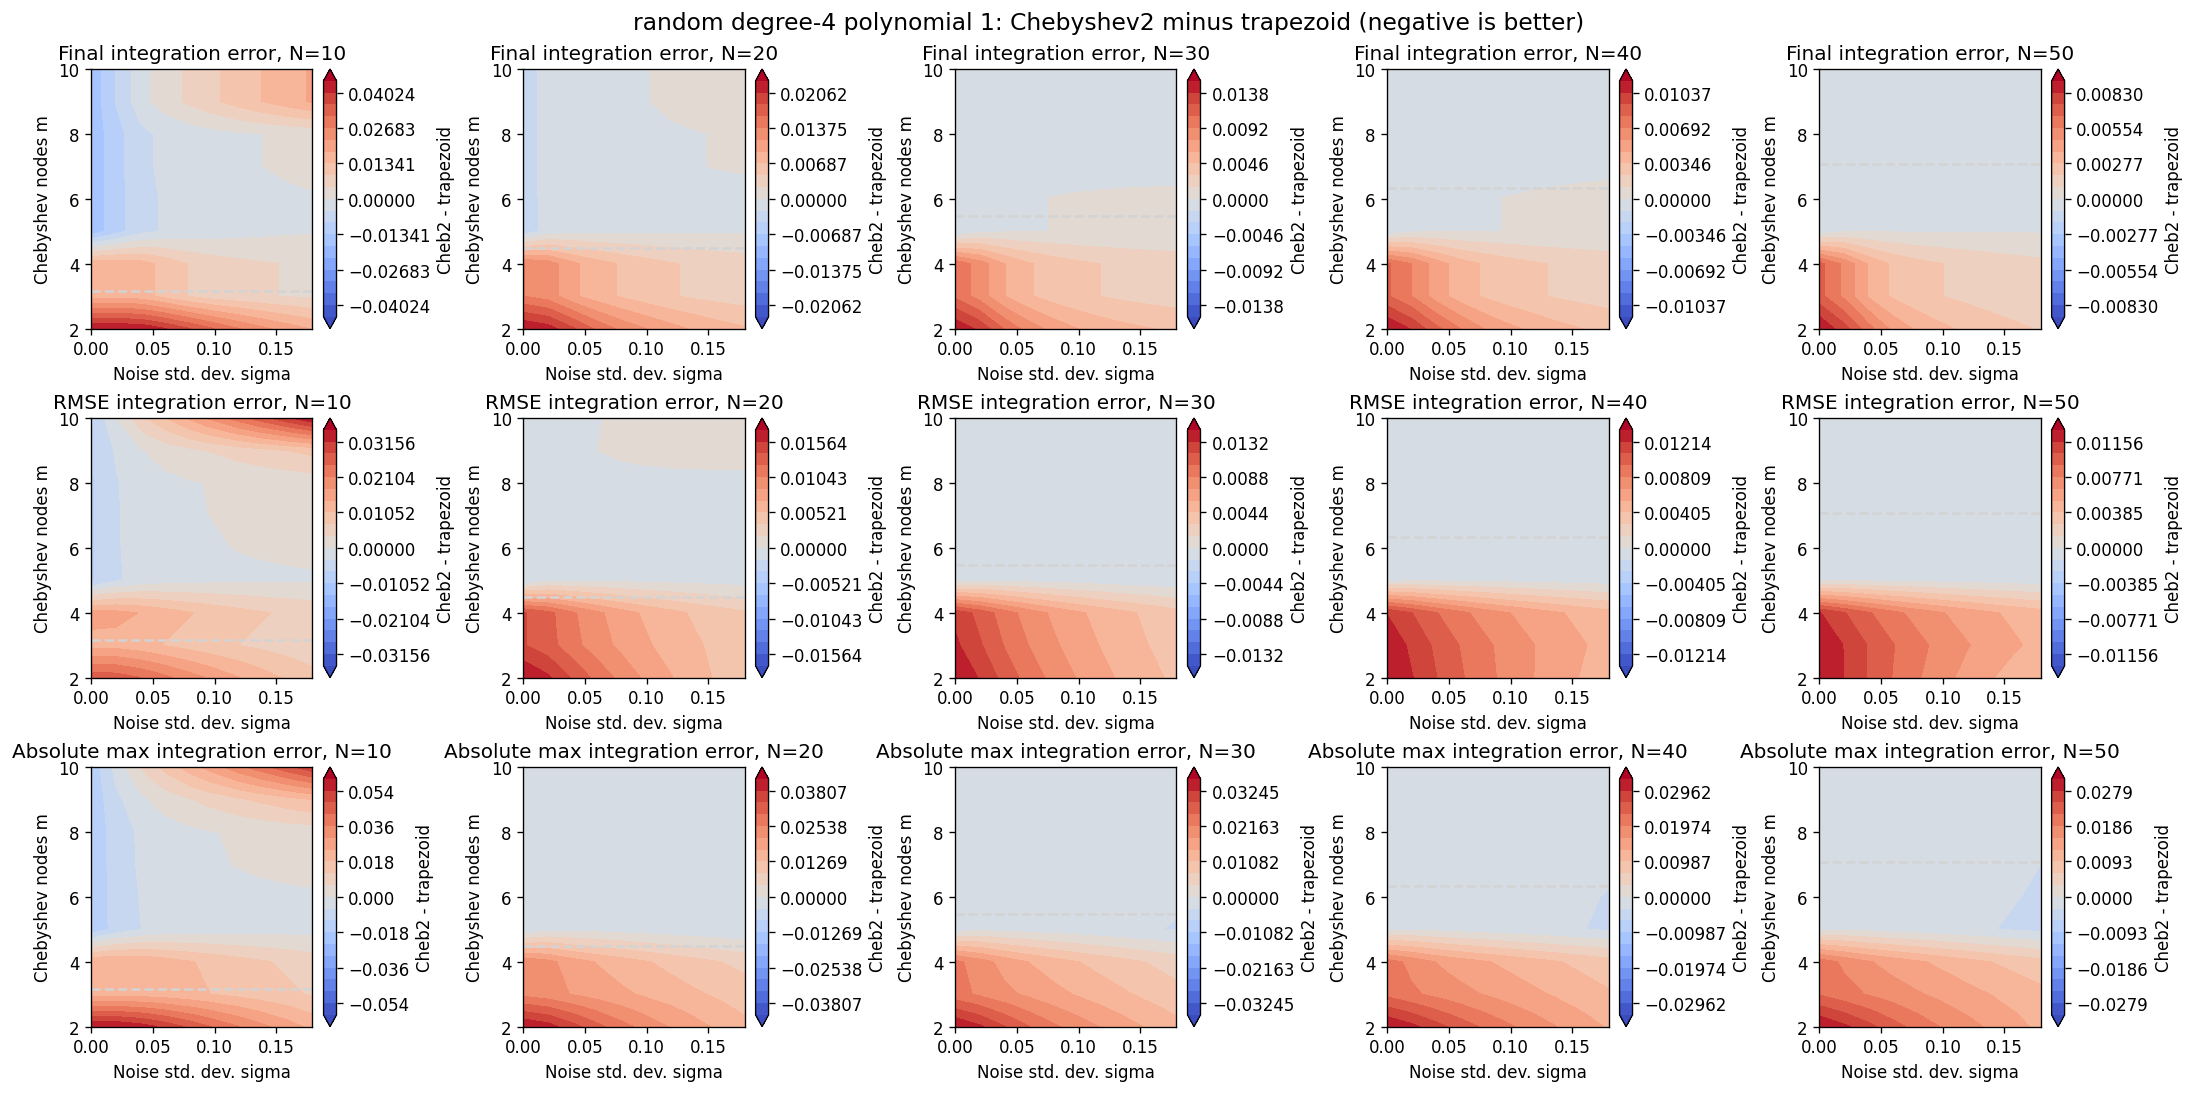

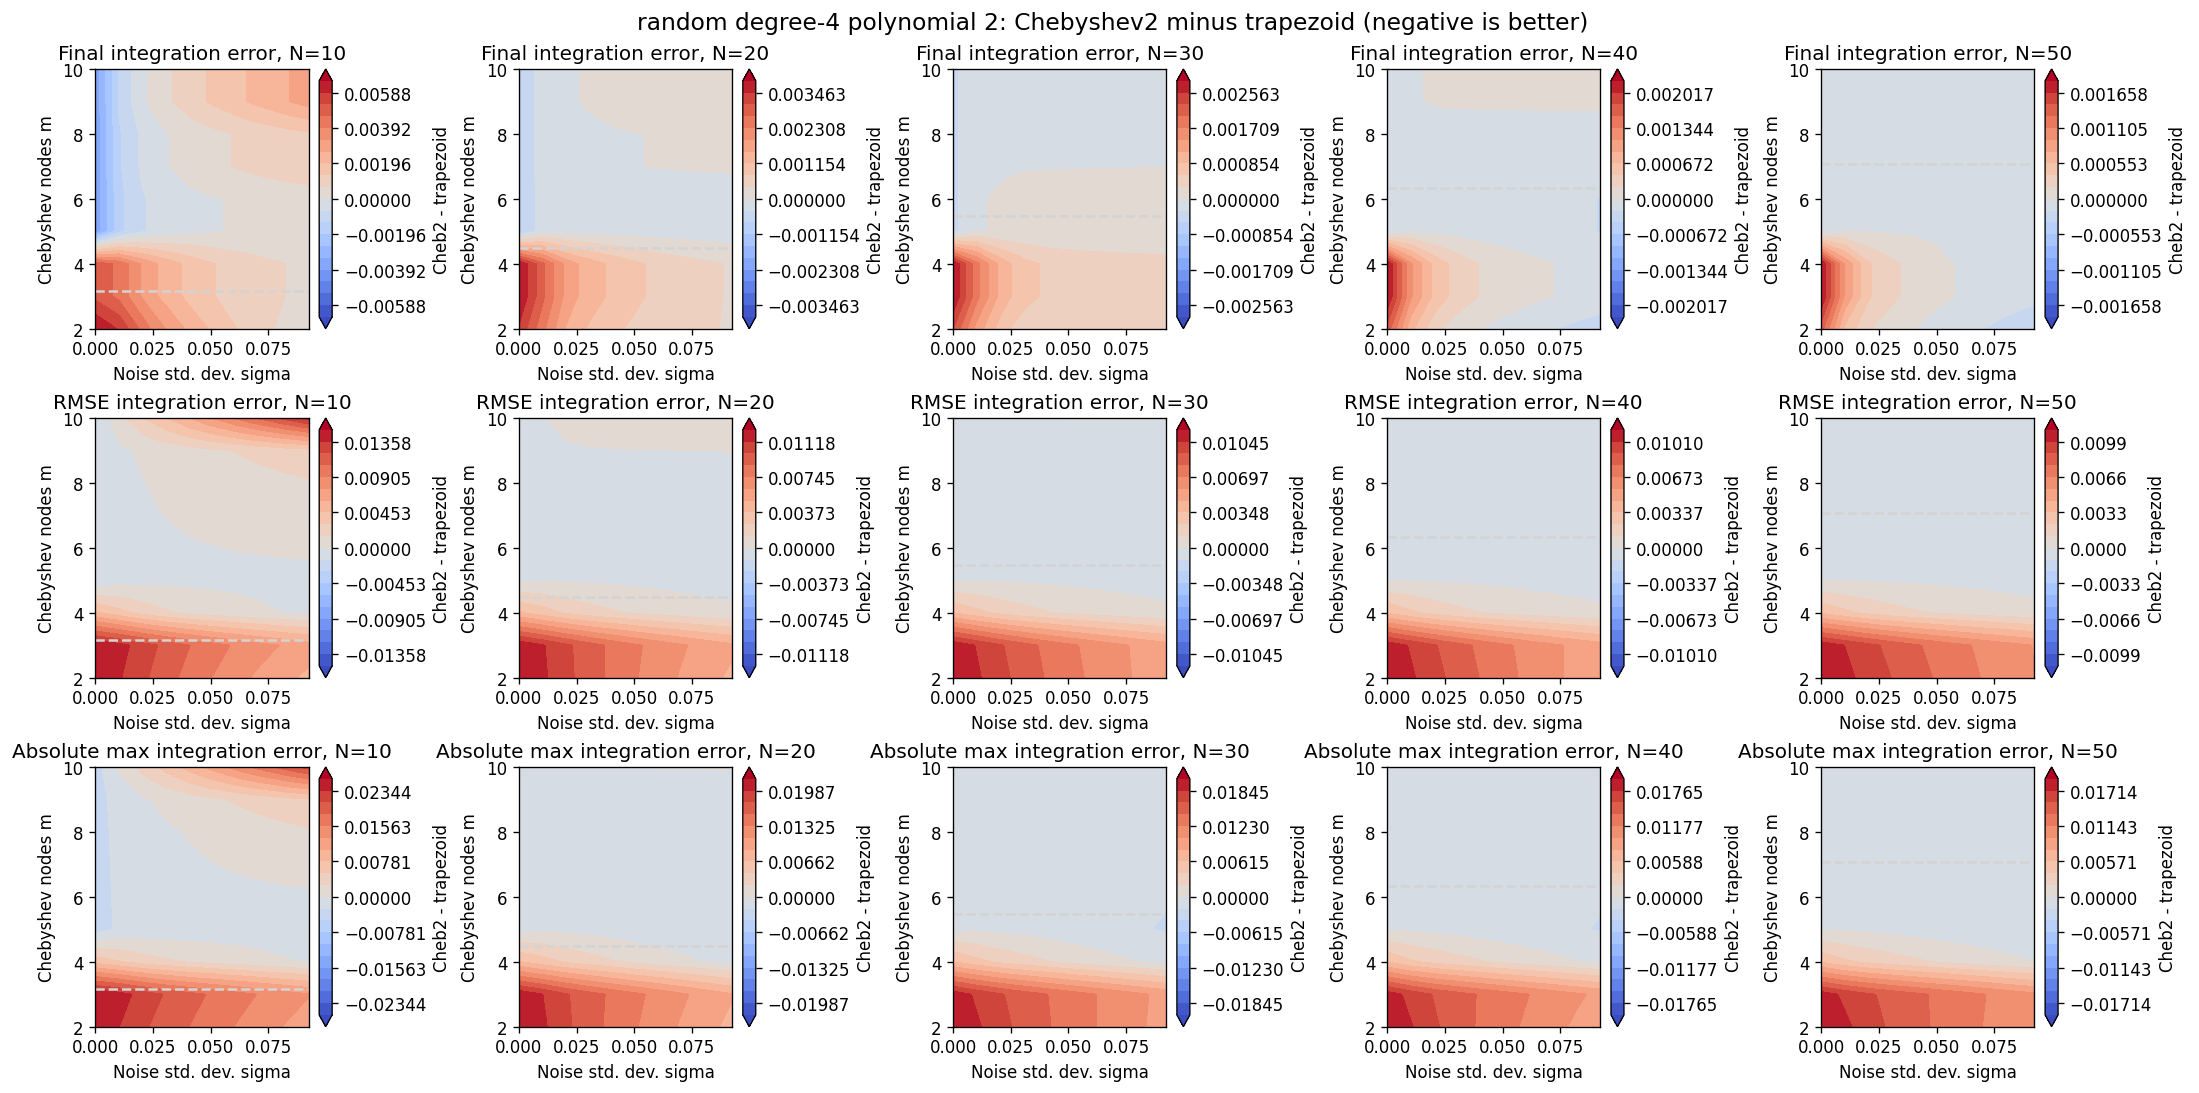

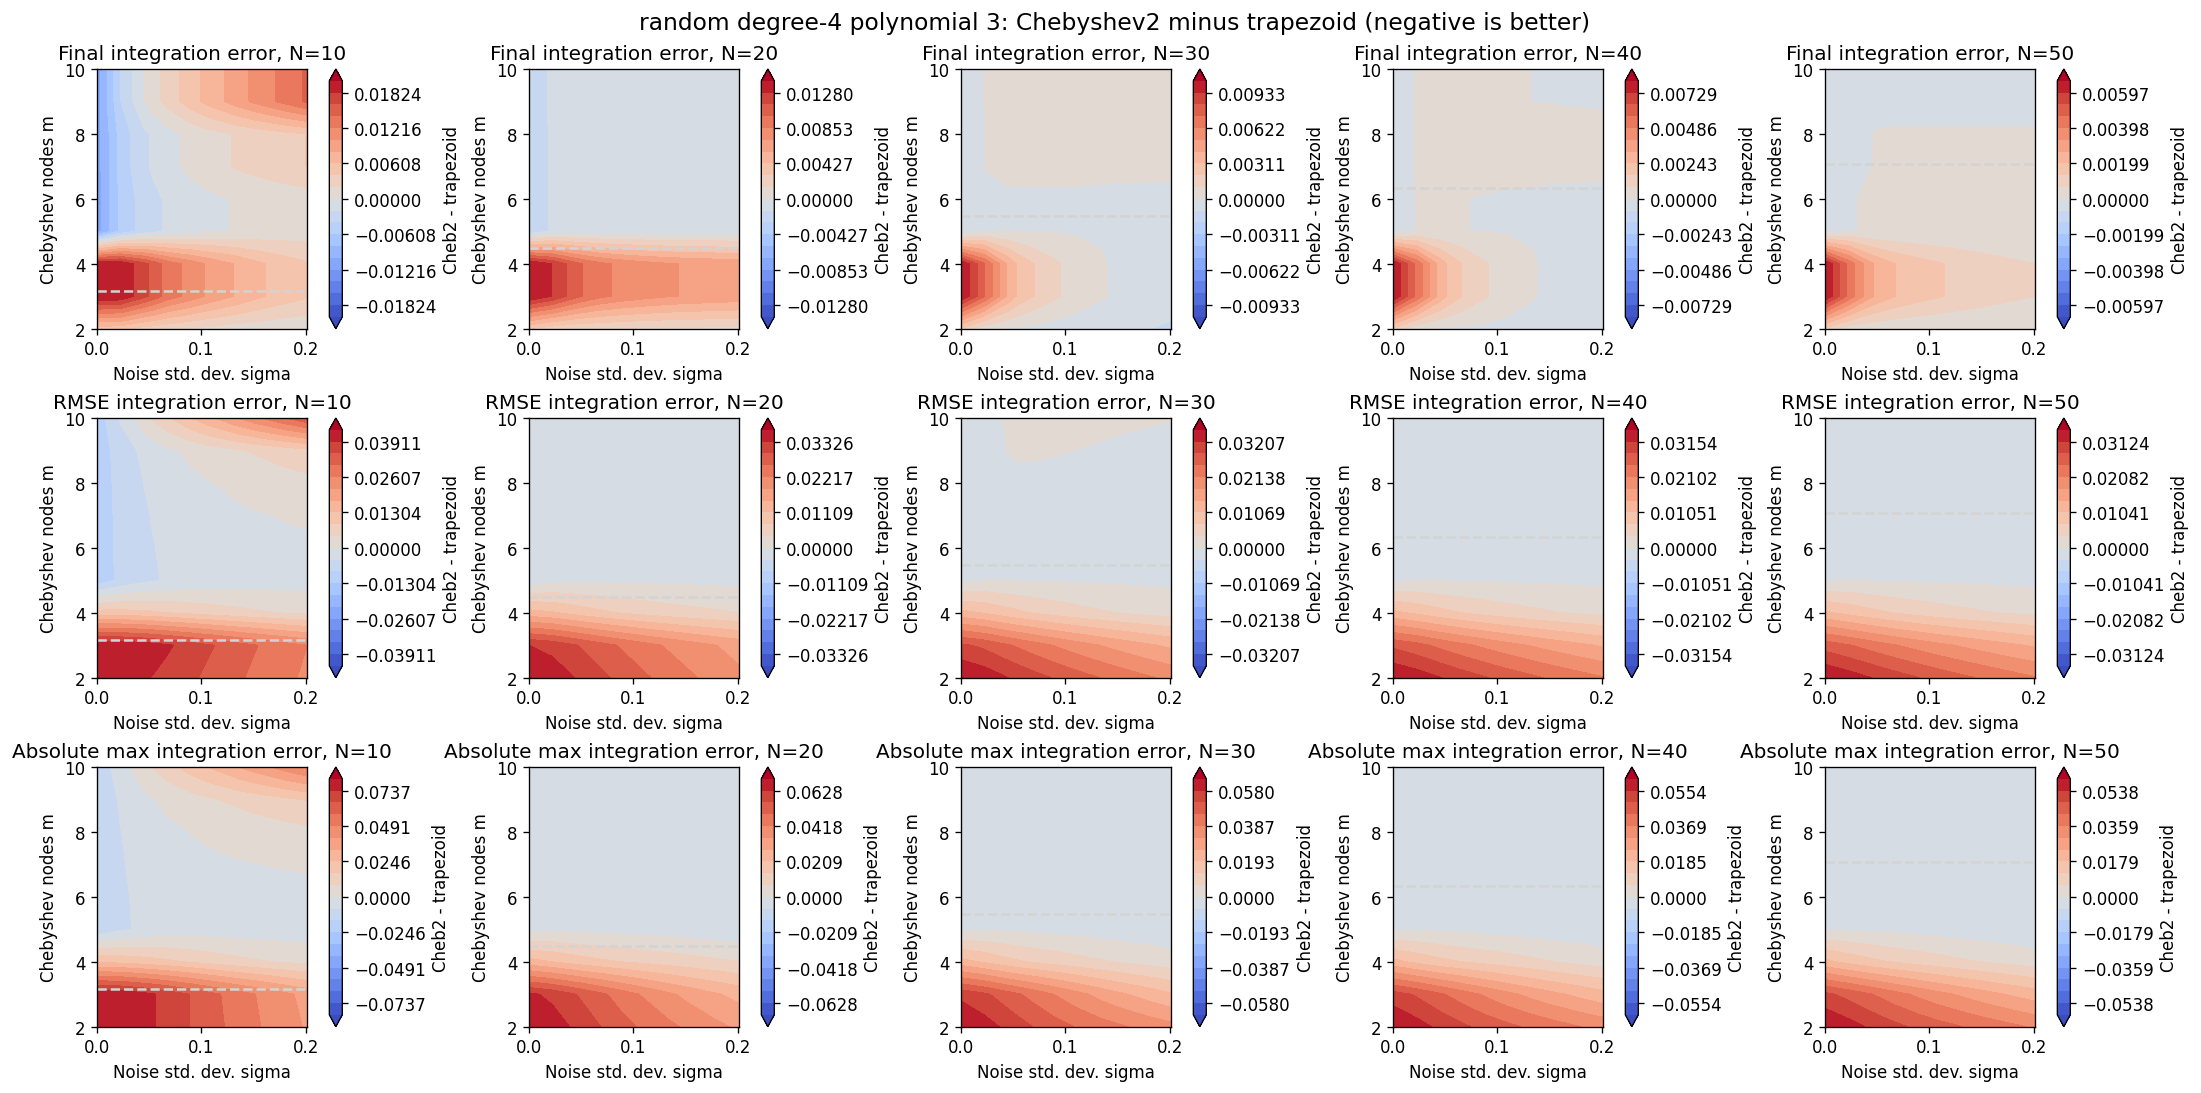

In [5]:
for function in FUNCTIONS:
    fig = plot_fixed_sample_comparison(
        comparisons,
        function_name=function.name,
        selected_sample_counts=SAMPLE_COUNTS,
        show_sqrt_sample_count=True,
    )
    display(fig)
    plt.close(fig)

In [6]:
summary = (
    comparisons.groupby(["function", "sample_count"])[["end_error", "rmse_error", "max_error"]]
    .median()
    .round(6)
)
summary

end_error  rmse_error  max_error
function                     sample_count                                  
random degree-4 polynomial 1 10             0.000568    0.001332   0.002476
                             20            -0.000075   -0.000094  -0.000805
                             30            -0.000132   -0.000194  -0.000934
                             40            -0.000069   -0.000160  -0.000866
                             50            -0.000058   -0.000114  -0.000659
random degree-4 polynomial 2 10             0.000522    0.000808   0.000977
                             20             0.000027   -0.000009  -0.000261
                             30             0.000013   -0.000049  -0.000364
                             40            -0.000033   -0.000060  -0.000368
                             50            -0.000025   -0.000046  -0.000287
random degree-4 polynomial 3 10             0.001867    0.001535   0.004835
                             20            -0.000809   -0.000522  -0.001238
                             30             0.000085   -0.000023  -0.000781
                             40             0.000032   -0.000074  -0.000789
                             50             0.000013   -0.000099  -0.000675

## Decision-oriented Plotly views

These views use the same comparison dataframe as the heatmaps above. Positive advantage is `trapezoid error - Chebyshev2 error`, so values above zero favor Chebyshev2. The diamond marks the best median RMSE `m`; the light grey dashed line is `sqrt(N)`. The table reports ideal `m` by metric plus a rank-based robust `m`.

In [7]:
for function in FUNCTIONS:
    display(
        plot_advantage_curves_by_sample_count(
            comparisons,
            function.name,
            selected_sample_counts=SAMPLE_COUNTS,
            metric="rmse_error",
            y_range_min_m=POLYNOMIAL_NODE_COUNT,
        )
    )
    display(
        plot_robust_m_table(
            comparisons,
            function.name,
            selected_sample_counts=SAMPLE_COUNTS,
        )
    )